In [5]:
import pandas as pd

# import data from csv-file
df = pd.read_csv("../data/events_full.csv")

In [6]:
print(df.columns)

Index(['event_id', 'name', 'url', 'image_url', 'date', 'time', 'status',
       'venue_id', 'fetched_at', 'category_id', 'segment', 'genre', 'subgenre',
       'venue_name', 'venue_city', 'venue_address', 'venue_lat', 'venue_lon',
       'price_min', 'price_max', 'price_currency'],
      dtype='str')


In [7]:

df['date'] = pd.to_datetime(df['date'])


df['month'] = df['date'].dt.month_name()


month_counts = df['month'].value_counts()

In [8]:
# Count the number of events per genre
df['genre'].value_counts()

genre
Theatre             93
Rock                20
Other               12
Hip-Hop/Rap          8
Dance/Electronic     7
Dance                4
Comedy               3
Family               3
Latin                3
Folk                 2
Alternative          2
Martial Arts         1
Food & Drink         1
Metal                1
Name: count, dtype: int64

In [9]:
# Find the top 3 dates with the highest number of events
df['date'].value_counts().nlargest(3)

date
2026-04-18    3
2026-05-02    3
2026-05-03    3
Name: count, dtype: int64

In [10]:
# Display top 10 most common venues
df['venue_name'].value_counts().nlargest(10)

venue_name
Tyrol                     93
Strawberry Arena          14
Cirkus                     5
Förbindelsehallen          3
B-K                        3
Dansens Hus Studioscen     2
Debaser Nova               2
Fryshuset                  2
3Arena                     2
Bio Skandia                1
Name: count, dtype: int64

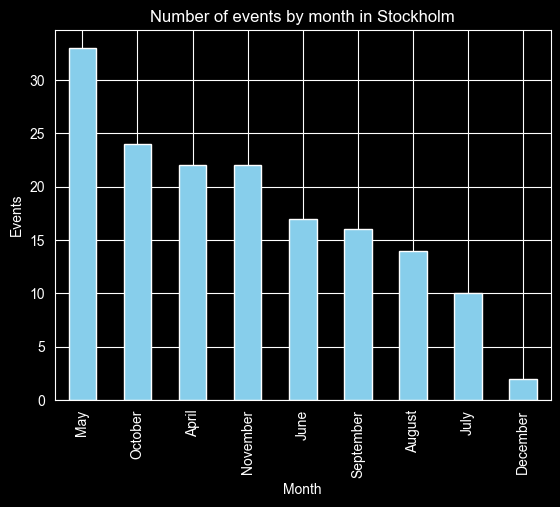

In [11]:
import matplotlib.pyplot as plt

# Count and visualize events per month using a bar chart
month_counts = df['month'].value_counts()

month_counts.plot(kind='bar', color='skyblue', edgecolor='white')

plt.title('Number of events by month in Stockholm')
plt.xlabel('Month')
plt.ylabel('Events')

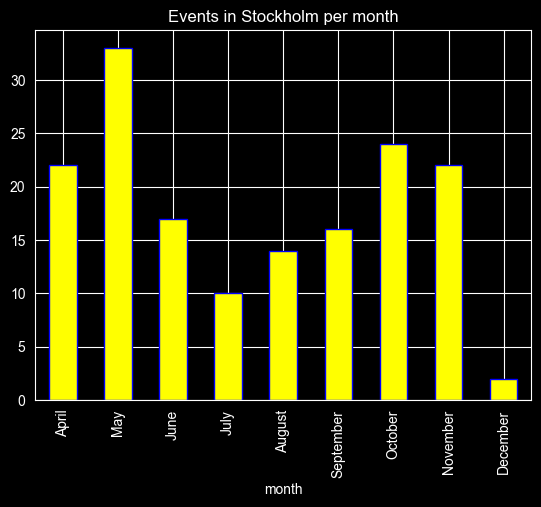

In [12]:
# Visualize events per month in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

counts = df['month'].value_counts()

counts_sorted = counts.reindex(month_order).dropna()

counts_sorted.plot(kind='bar', color='yellow', edgecolor='blue')
plt.title("Events in Stockholm per month")

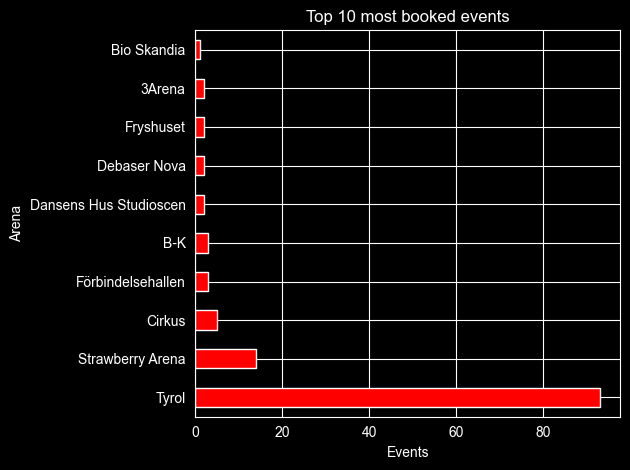

In [13]:
# Visualize the top 10 venues with the most events
venue_counts = df['venue_name'].value_counts()

top_10_venues = venue_counts.head(10)

top_10_venues.plot(kind='barh', color='red')

plt.title("Top 10 most booked events")
plt.xlabel("Events")
plt.ylabel('Arena')
plt.tight_layout()

In [14]:
import duckdb
# Query to count events by day of the week
duckdb.sql("""
SELECT day_of_week, COUNT(*) AS num_events
FROM df
GROUP BY day_of_week
ORDER BY num_events DESC
""")

BinderException: Binder Error: Referenced column "day_of_week" not found in FROM clause!
Candidate bindings: "date", "category_id"

In [ ]:
# Find the top 5 venues with the most unique set of genres
duckdb.sql("""
SELECT venue_name, COUNT(DISTINCT genre) AS unique_genres
FROM df
WHERE venue_name IS NOT NULL
GROUP BY venue_name
ORDER BY unique_genres DESC
LIMIT 5
""")

In [ ]:
# Count events grouped by month and segment
duckdb.sql("""
SELECT month_name, segment, COUNT(*) AS num_events
FROM df
GROUP BY month_name, segment
ORDER BY month_name, num_events DESC
""")

In [ ]:
# Filter for events categorized as Rock
rock_query = """
SELECT name, venue_name, date, genre
FROM df
WHERE genre LIKE '%Rock%'
"""

rock_events = duckdb.query(rock_query).to_df()
print("Rock conserts in Stockholm:") # Pitbull WTF?
print(rock_events)

In [ ]:
# Show events as 'Day' or 'Evening' based on the hour
duckdb.sql("""
SELECT
    CASE WHEN hour >= 18 THEN 'Evening' ELSE 'Day' END AS time_of_day,
    COUNT(*) AS num_events
FROM df
WHERE hour IS NOT NULL
GROUP BY time_of_day
""")

In [ ]:
# Styled pie chart showing top 10 genre distribution
df['genre'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=180,
    pctdistance=0.80,
    textprops={'color':"red", 'weight':'bold', 'fontsize':10}
)

plt.title('Genre distribution in Stockholm', color='white')
plt.ylabel('')

In [ ]:
import duckdb
# Create a subset containing only events in the 'Music' segment
music_query = """
SELECT *
FROM df
WHERE segment = 'Music'
"""

df_music = duckdb.query(music_query).to_df()

In [ ]:
# Compare the size of the full dataset vs the music subset
print(f"Number of rows in full set: {len(df)}")
print(f"Number of rows in music only: {len(df_music)}")

In [ ]:
# Visualize the distribution of sub-genres within the Music segment
df_music['genre'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colormap='Set1',
    textprops={'color':"white", 'weight':'bold', 'fontsize':8}
)
plt.title("Music genres in Stockholm")
plt.ylabel('')